# 📊 Deep Research — Pairwise Report Evaluation for the domain `NLP`

This notebook evaluates **all pairwise combinations** of the deep research generated reports using **YESciEval pairwise rubrics**.

### Steps
1. Read the research **question from the domain CSV** 
2. Load **all four config reports** from the report pool
3. Enumerate all **6 config pairs** 
4. For each pair — run the YESciEval pairwise judge across all rubrics
5. Aggregate rubric scores → **category-level scores for A and B**
6. Display a **6-panel grouped comparison plot** per pair
7. Save JSON + CSV outputs per pair

---
**Prerequisites:** `pip install yescieval python-dotenv matplotlib numpy`

## 1 — Imports & Setup

In [1]:
!pip install yescieval==0.10.0 python-dotenv matplotlib 

In [5]:
import re, json, csv, itertools
from pathlib import Path
from typing import Dict, Tuple, List
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from IPython.display import display, Markdown
from dotenv import load_dotenv
import torch
from datetime import datetime, timezone
load_dotenv()
print("✅ Core imports loaded")

✅ Core imports loaded


In [6]:
from yescieval import CustomAutoJudge, VocabularyInjector, ExampleInjector
from yescieval.rubric.pairwise.depth      import TemporalPrecision, CausalReasoning, MechanisticUnderstanding
from yescieval.rubric.pairwise.breadth    import ContextCoverage, ScopeCoverage, DimensionCoverage, ScaleCoverage, MethodCoverage
from yescieval.rubric.pairwise.rigor      import EpistemicCalibration, ExplicitUncertainty, QuantitativeEvidenceAndUncertainty
# from yescieval.rubric.pairwise.innovation import StateOfTheArtAndNovelty
# from yescieval.rubric.pairwise.gap        import GapIdentification
print("✅ YESciEval pairwise imports loaded")

✅ YESciEval pairwise imports loaded


## 2 — Configuration

Set the domain, model, and populate the report pool. All 6 pairs are evaluated automatically.

In [15]:
# --- USER CONFIGURATION ---

QUESTIONS_CSV  = "/nfs/home/gillm/deep-research/data/nlp/49-questions-nlp.csv"
OUTPUT_DIR     = "/nfs/home/gillm/deep-research/eval/output-nlp"
DOMAIN         = "nlp"          
MODEL_ID       = "Qwen/Qwen3-1.7B"
DEVICE         = torch.device("cuda" if torch.cuda.is_available() else "cpu")         
HF_TOKEN       = "your_huggingface_token_here"
MAX_NEW_TOKENS = 2048

# ── Report pool ──────────────────────────────────────────────────────────────
REPORT_POOL = {
    'd1_b1': '/nfs/home/gillm/deep-research/data/nlp/reports/orkg-ask/o3-mini/1_o3-mini_orkg_d1_b1.md',
    'd1_b4': '/nfs/home/gillm/deep-research/data/nlp/reports/orkg-ask/o3-mini/1_o3-mini_orkg_d1_b4.md',
    'd4_b1': '/nfs/home/gillm/deep-research/data/nlp/reports/orkg-ask/o3-mini/1_o3-mini_orkg_d4_b1.md',
    'd4_b4': '/nfs/home/gillm/deep-research/data/nlp/reports/orkg-ask/o3-mini/1_o3-mini_orkg_d4_b4.md',
}

ALL_PAIRS = list(itertools.combinations(REPORT_POOL.keys(), 2))
# → [('d1_b1','d1_b4'), ('d1_b1','d4_b1'), ('d1_b1','d4_b4'),
#    ('d1_b4','d4_b1'), ('d1_b4','d4_b4'), ('d4_b1','d4_b4')]

# Category → list of (RubricClass, weight) tuples
CATEGORIES: Dict[str, List[Tuple[type, float]]] = {
    "depth": [
        (TemporalPrecision,         1/3),
        (CausalReasoning,           1/3),
        (MechanisticUnderstanding,  1/3),
    ],
    "breadth": [
        (ContextCoverage,   1/5),
        (ScopeCoverage,     1/5),
        (DimensionCoverage, 1/5),
        (MethodCoverage,    1/5),
        (ScaleCoverage,     1/5),
    ],
    "rigor": [
        (EpistemicCalibration,               1/3),
        (ExplicitUncertainty,                1/3),
        (QuantitativeEvidenceAndUncertainty, 1/3),
    ],
    # "innovation": [
    #     (StateOfTheArtAndNovelty, 1.0),
    # ],
    # "gap": [
    #     (GapIdentification, 1.0),
    # ],
}

RATING_MIN, RATING_MAX = 1, 5

print(f"Report pool : {list(REPORT_POOL.keys())}")
print(f"Pairs to run: {len(ALL_PAIRS)} — {ALL_PAIRS}")
print(f"Model       : {MODEL_ID}")
print(f"Categories  : {list(CATEGORIES.keys())}")

cuda
Report pool : ['d1_b1', 'd1_b4', 'd4_b1', 'd4_b4']
Pairs to run: 6 — [('d1_b1', 'd1_b4'), ('d1_b1', 'd4_b1'), ('d1_b1', 'd4_b4'), ('d1_b4', 'd4_b1'), ('d1_b4', 'd4_b4'), ('d4_b1', 'd4_b4')]
Model       : Qwen/Qwen3-1.7B
Categories  : ['depth', 'breadth', 'rigor']


## 3 — Helper Functions

In [16]:
def parse_config(stem: str) -> str:
    """Extracts dX_bY from filename, e.g. 1_o3-mini_orkg_d1_b1 -> d1_b1."""
    m = re.search(r'd(\d+)_b(\d+)', stem)
    return f"d{m.group(1)}_b{m.group(2)}" if m else 'd1_b1'


def parse_report_number(stem: str) -> int:
    """Extracts the leading report number from filename, e.g. 1_o3-mini -> 1."""
    m = re.match(r'(\d+)[_\-]', stem)
    return int(m.group(1)) if m else -1


def load_question_from_csv(csv_path: str, report_number: int) -> str:
    """
    Reads the report title by ROW POSITION (1-based) from the NLP CSV.
    The NLP CSV uses a 'title' column (vs ecology's 'Your research question.' column).
    All reports share the same question; row is derived from the first pool entry.
    """
    encodings_to_try = ['cp1252', 'utf-8', 'utf-8-sig', 'latin-1']
    for encoding in encodings_to_try:
        try:
            with open(csv_path, newline='', encoding=encoding) as f:
                reader = csv.DictReader(f)
                for row_num, row in enumerate(reader, start=1):
                    if row_num == report_number:
                        q = row.get('title', '').strip()
                        return q if q else f'Empty title at row {report_number}'
            return f'Row {report_number} not found in CSV (file has fewer rows)'
        except UnicodeDecodeError:
            continue
    return 'Could not open CSV with any known encoding'


def parse_pairwise_judge_result(result, rubric_name: str) -> Tuple[int, int, str, str]:
    """
    Extracts (rating_a, rating_b, rationale_a, rationale_b) from a pairwise judge result.

    Expected JSON shape:
    {
        "RubricName": {
            "ResponseA": {"rating": 4, "rationale": "..."},
            "ResponseB": {"rating": 3, "rationale": "..."}
        }
    }
    """
    if isinstance(result, str):
        cleaned = re.sub(r'<think>.*?</think>', '', result, flags=re.DOTALL).strip()
        json_str = None
        depth, start = 0, None
        for i, ch in enumerate(cleaned):
            if ch == '{':
                if depth == 0: start = i
                depth += 1
            elif ch == '}':
                depth -= 1
                if depth == 0 and start is not None:
                    json_str = cleaned[start:i+1]
                    break
        if json_str:
            try:
                result = json.loads(json_str)
            except json.JSONDecodeError:
                pass
        if isinstance(result, str):
            return 0, 0, '', result

    if isinstance(result, dict):
        inner = result.get(rubric_name) or result.get(rubric_name.lower())
        if inner is None and len(result) == 1:
            inner = next(iter(result.values()))
        if isinstance(inner, dict):
            resp_a = inner.get('ResponseA', {})
            resp_b = inner.get('ResponseB', {})
            return (
                int(resp_a.get('rating',    0)),
                int(resp_b.get('rating',    0)),
                str(resp_a.get('rationale', '')),
                str(resp_b.get('rationale', '')),
            )
        if 'ResponseA' in result:
            resp_a = result['ResponseA']
            resp_b = result.get('ResponseB', {})
            return (
                int(resp_a.get('rating',    0)),
                int(resp_b.get('rating',    0)),
                str(resp_a.get('rationale', '')),
                str(resp_b.get('rationale', '')),
            )
        return 0, 0, '', str(result)

    if hasattr(result, 'ResponseA') and hasattr(result, 'ResponseB'):
        resp_a = result.ResponseA
        resp_b = result.ResponseB
        return (
            int(getattr(resp_a, 'rating',    0)),
            int(getattr(resp_b, 'rating',    0)),
            str(getattr(resp_a, 'rationale', '')),
            str(getattr(resp_b, 'rationale', '')),
        )
    return 0, 0, '', str(result)


def compute_category_score(rubric_scores: List[Tuple[float, float]]) -> float:
    """
    Weighted mean of (score, weight) pairs, normalised to 0.0-1.0.
    Formula: (weighted_mean - 1) / (5 - 1)
    """
    total_w = sum(w for _, w in rubric_scores)
    if not total_w:
        return 0.0
    weighted_mean = sum(s * w for s, w in rubric_scores) / total_w
    return round((weighted_mean - 1) / (RATING_MAX - RATING_MIN), 4)


def run_pair(cfg_a, cfg_b, report_a_md, report_b_md, question, judge):
    """
    Runs the full pairwise evaluation for one (cfg_a, cfg_b) combination.
    Returns (rubric_raw, category_scores, overall_a, overall_b).
    """
    rubric_raw:      Dict[str, dict]             = {}
    category_scores: Dict[str, Dict[str, float]] = {}

    for cat_name, rubric_list in CATEGORIES.items():
        print(f"  📂 {cat_name.upper()}")
        cat_rubric_a: List[Tuple[float, float]] = []
        cat_rubric_b: List[Tuple[float, float]] = []

        for RubricClass, weight in rubric_list:
            rname = RubricClass.__name__
            print(f"     🔎 [{rname}] (w={weight:.3f}) ...")
            rubric = RubricClass(
                papers={},
                question=question,
                answer_a=report_a_md,
                answer_b=report_b_md,
                domain=DOMAIN,
                vocabulary=VocabularyInjector(),
                example=ExampleInjector(),
            )
            raw = judge.judge(rubric=rubric, max_new_tokens=MAX_NEW_TOKENS)
            rating_a, rating_b, rat_a, rat_b = parse_pairwise_judge_result(raw, rname)
            rubric_raw[rname] = {
                'ResponseA': {'rating': rating_a, 'rationale': rat_a},
                'ResponseB': {'rating': rating_b, 'rationale': rat_b},
                'weight_in': {cat_name: weight},
            }
            print(f"        ResponseA={rating_a}/5  |  ResponseB={rating_b}/5")
            cat_rubric_a.append((float(rating_a), weight))
            cat_rubric_b.append((float(rating_b), weight))

        score_a = compute_category_score(cat_rubric_a)
        score_b = compute_category_score(cat_rubric_b)
        category_scores[cat_name] = {'a': score_a, 'b': score_b}
        print(f"     ✅ {cat_name}  {cfg_a}={score_a:.2f}  {cfg_b}={score_b:.2f}")

    overall_a = round(sum(v['a'] for v in category_scores.values()) / len(category_scores), 4)
    overall_b = round(sum(v['b'] for v in category_scores.values()) / len(category_scores), 4)
    return rubric_raw, category_scores, overall_a, overall_b

print("✅ Helpers defined")

✅ Helpers defined


## 4 — Load All Reports & Read Question from CSV

In [17]:
# Load all reports from the pool 
loaded_reports: Dict[str, str] = {}
for cfg, path in REPORT_POOL.items():
    p = Path(path).resolve()
    if not p.exists():
        raise FileNotFoundError(f'Report not found for {cfg}: {p}')
    loaded_reports[cfg] = p.read_text(encoding='utf-8', errors='ignore')
    print(f"✅ {cfg}: {p.name}  ({len(loaded_reports[cfg]):,} chars)")

# Derive the question row from the first pool entry's filename
first_stem = Path(next(iter(REPORT_POOL.values()))).stem
report_num = parse_report_number(first_stem)
question   = load_question_from_csv(QUESTIONS_CSV, report_num)

# Extract engine string for plot titles (reused across all pairs)
engine_m   = re.search(r'\d+_(.*?)_orkg', first_stem)
engine_str = engine_m.group(1) if engine_m else first_stem

print(f"\nReport Number    : {report_num}")
print(f"Research Question: {question}")

✅ d1_b1: 1_o3-mini_orkg_d1_b1.md  (12,662 chars)
✅ d1_b4: 1_o3-mini_orkg_d1_b4.md  (13,938 chars)
✅ d4_b1: 1_o3-mini_orkg_d4_b1.md  (13,334 chars)
✅ d4_b4: 1_o3-mini_orkg_d4_b4.md  (21,197 chars)

Report Number    : 1
Research Question: Robust Defenses against Many-Shot Jailbreaking


## 5 — Initialise the YESciEval Judge

In [18]:
print(f"⏳ Loading {MODEL_ID} on {DEVICE} ...")
judge = CustomAutoJudge()
judge.from_pretrained(model_id=MODEL_ID, device=DEVICE, token=HF_TOKEN or None)
print(f"✅ Judge ready")
# Record evaluation start time immediately after judge is ready
EVAL_START_TIME = datetime.now(timezone.utc)
print(f"🕐 Evaluation start time (UTC): {EVAL_START_TIME.isoformat()}")


⏳ Loading Qwen/Qwen3-1.7B on cuda ...


`torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 311/311 [00:00<00:00, 349.79it/s]
The tied weights mapping and config for this model specifies to tie model.embed_tokens.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


✅ Judge ready
🕐 Evaluation start time (UTC): 2026-05-04T12:56:14.324662+00:00


## 6 — Run All Pairwise Evaluations

Iterates over the **6 config pairs**. For each pair,
every rubric scores `answer_a` and `answer_b` independently via `ResponseA` /
`ResponseB`. Results are collected in `all_pair_results` keyed by `cfg_a_vs_cfg_b`.

In [19]:
all_pair_results: Dict[str, dict] = {}

for cfg_a, cfg_b in ALL_PAIRS:
    pair_key = f'{cfg_a}_vs_{cfg_b}'
    print(f"\n{'='*60}")
    print(f"🔁 Pair {ALL_PAIRS.index((cfg_a, cfg_b)) + 1}/{len(ALL_PAIRS)}: {cfg_a}  vs  {cfg_b}")
    print(f"{'='*60}")

    rubric_raw, category_scores, overall_a, overall_b = run_pair(
        cfg_a, cfg_b,
        loaded_reports[cfg_a],
        loaded_reports[cfg_b],
        question,
        judge,
    )

    all_pair_results[pair_key] = {
        'config_a':        cfg_a,
        'config_b':        cfg_b,
        'rubric_scores':   rubric_raw,
        'category_scores': category_scores,
        'overall_a':       overall_a,
        'overall_b':       overall_b,
    }
    print(f"\n  🏁 {pair_key}  overall  {cfg_a}={overall_a:.2f}  {cfg_b}={overall_b:.2f}  (0-1 scale)")

print(f"\n✅ All {len(ALL_PAIRS)} pairs evaluated.")


🔁 Pair 1/6: d1_b1  vs  d1_b4
  📂 DEPTH
     🔎 [TemporalPrecision] (w=0.333) ...
        ResponseA=4/5  |  ResponseB=4/5
     🔎 [CausalReasoning] (w=0.333) ...
        ResponseA=5/5  |  ResponseB=5/5
     🔎 [MechanisticUnderstanding] (w=0.333) ...
        ResponseA=3/5  |  ResponseB=4/5
     ✅ depth  d1_b1=0.75  d1_b4=0.83
  📂 BREADTH
     🔎 [ContextCoverage] (w=0.200) ...
        ResponseA=5/5  |  ResponseB=5/5
     🔎 [ScopeCoverage] (w=0.200) ...
        ResponseA=5/5  |  ResponseB=4/5
     🔎 [DimensionCoverage] (w=0.200) ...
        ResponseA=5/5  |  ResponseB=5/5
     🔎 [MethodCoverage] (w=0.200) ...
        ResponseA=5/5  |  ResponseB=5/5
     🔎 [ScaleCoverage] (w=0.200) ...
        ResponseA=5/5  |  ResponseB=4/5
     ✅ breadth  d1_b1=1.00  d1_b4=0.90
  📂 RIGOR
     🔎 [EpistemicCalibration] (w=0.333) ...
        ResponseA=5/5  |  ResponseB=5/5
     🔎 [ExplicitUncertainty] (w=0.333) ...
        ResponseA=1/5  |  ResponseB=1/5
     🔎 [QuantitativeEvidenceAndUncertainty] (w=0.333) .

## 7 — Raw Rubric Scores Plot (1–5)

For each **individual rubric** (TemporalPrecision, CausalReasoning, MechanisticUnderstanding, etc.)
we plot the raw 1–5 ratings the judge assigned to **Config A** (dark blue) and **Config B** (light blue)
across all 6 pair combinations. One panel per rubric, grouped by dimension.


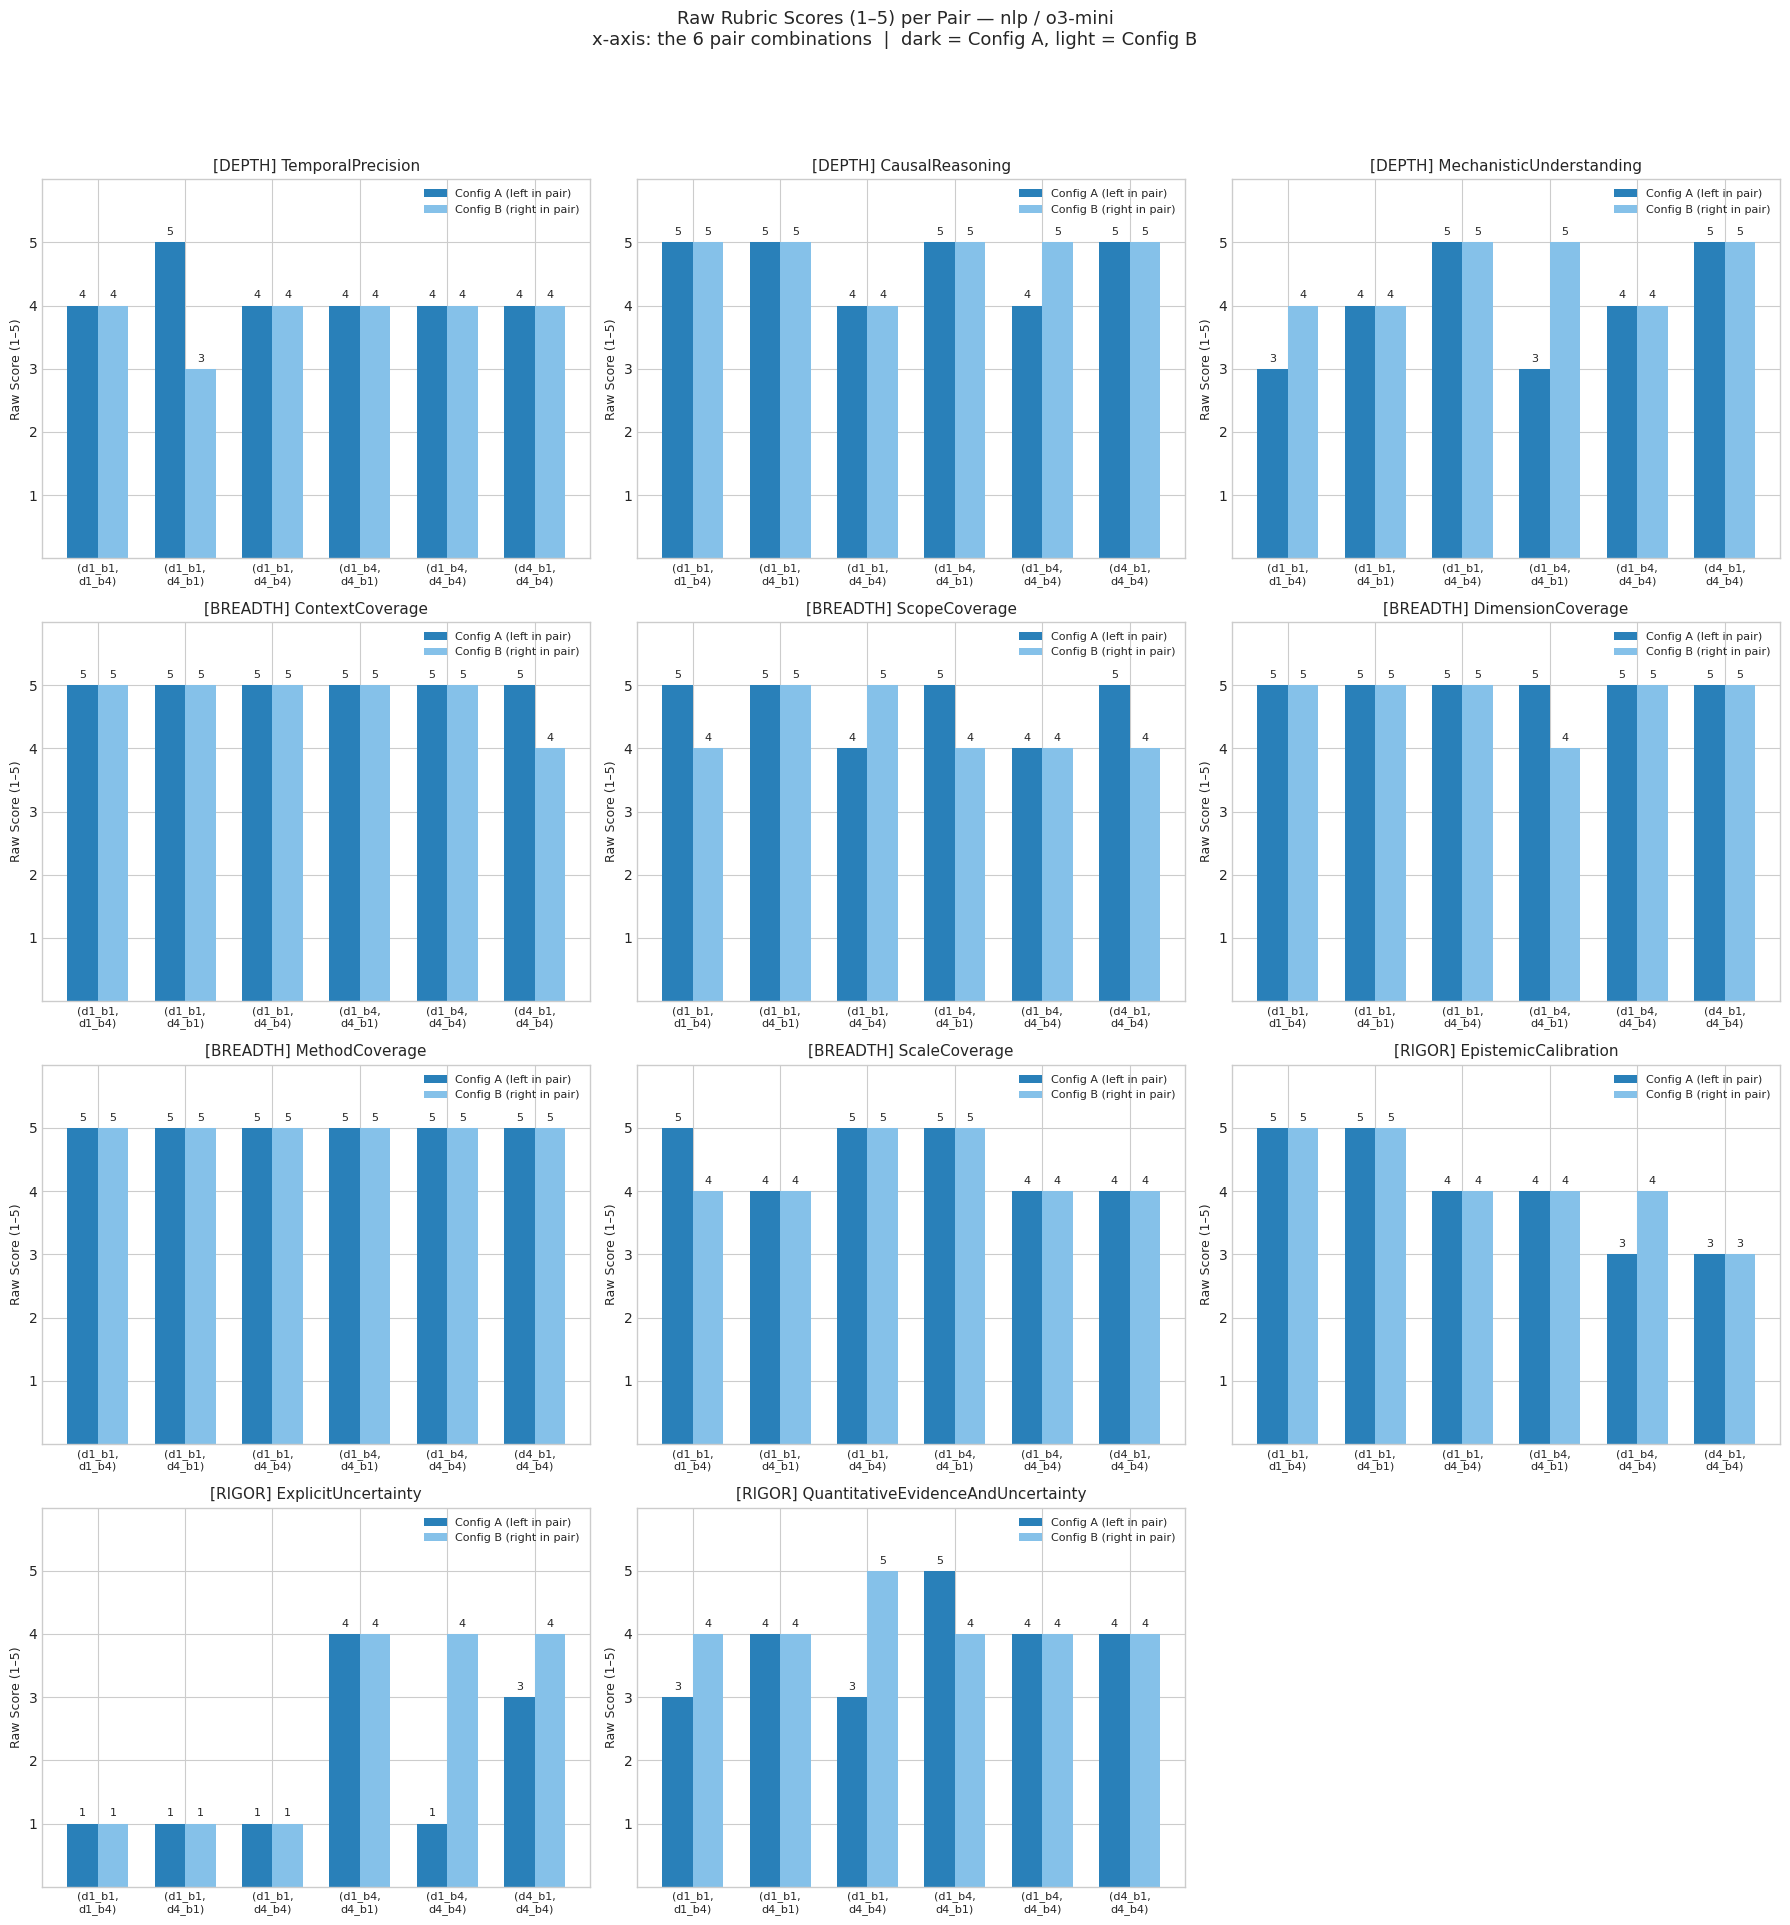

📊 Per-rubric raw score plot rendered
💾 Per-rubric raw score plot → /nfs/home/gillm/deep-research/eval/output-nlp/pairwise_raw_rubric_scores_nlp.png


In [22]:
# ── Raw rubric scores (1–5) per rubric per pair ──────────────────────────────
# x-axis  : the 6 pair combinations
# y-axis  : raw rating (1–5) from the judge
# bars    : two per pair — Config A (dark blue) and Config B (light blue)
# panels  : one per rubric, grouped by category/dimension

# Map each category to its ordered rubric names 
RUBRIC_ORDER = {
    'depth':   ['TemporalPrecision', 'CausalReasoning', 'MechanisticUnderstanding'],
    'breadth': ['ContextCoverage', 'ScopeCoverage', 'DimensionCoverage', 'MethodCoverage', 'ScaleCoverage'],
    'rigor':   ['EpistemicCalibration', 'ExplicitUncertainty', 'QuantitativeEvidenceAndUncertainty'],
    # 'innovation': ['StateOfTheArtAndNovelty'],
    # 'gap':        ['GapIdentification'],
}

CATEGORY_COLORS = {
    'depth':   ('#2980b9', '#85c1e9'),  
    'breadth': ('#2980b9', '#85c1e9'),   
    'rigor':   ('#2980b9', '#85c1e9'),  
}

ALL_RUBRICS_FLAT = [
    (cat, rname)
    for cat, rubrics in RUBRIC_ORDER.items()
    for rname in rubrics
]

n_rubrics  = len(ALL_RUBRICS_FLAT)
n_pairs    = len(ALL_PAIRS)        # 6
xs_pairs   = np.arange(n_pairs)
BAR_W_RUB  = 0.35

n_cols_rub = 3
n_rows_rub = int(np.ceil(n_rubrics / n_cols_rub))

plt.style.use('seaborn-v0_8-whitegrid')
fig_rub, axes_rub = plt.subplots(
    n_rows_rub, n_cols_rub,
    figsize=(6 * n_cols_rub, 5 * n_rows_rub),
    squeeze=False,
)
axes_rub_flat = axes_rub.ravel()

for pi, (cat, rname) in enumerate(ALL_RUBRICS_FLAT):
    ax = axes_rub_flat[pi]
    color_a, color_b = CATEGORY_COLORS.get(cat, ('#2980b9', '#85c1e9'))

    ratings_a, ratings_b = [], []
    for cfg_a, cfg_b in ALL_PAIRS:
        pair_key = f'{cfg_a}_vs_{cfg_b}'
        rubric_scores = all_pair_results[pair_key]['rubric_scores']
        rubric_entry  = rubric_scores.get(rname, {})
        ra = rubric_entry.get('ResponseA', {}).get('rating', 0)
        rb = rubric_entry.get('ResponseB', {}).get('rating', 0)
        ratings_a.append(ra)
        ratings_b.append(rb)

    ax.bar(
        xs_pairs - BAR_W_RUB / 2, ratings_a,
        width=BAR_W_RUB, color=color_a, label='Config A (left in pair)',
    )
    ax.bar(
        xs_pairs + BAR_W_RUB / 2, ratings_b,
        width=BAR_W_RUB, color=color_b, label='Config B (right in pair)',
    )

    # Value labels
    for x, va, vb in zip(xs_pairs, ratings_a, ratings_b):
        if va:
            ax.text(x - BAR_W_RUB / 2, va + 0.08, str(va),
                    ha='center', va='bottom', fontsize=8)
        if vb:
            ax.text(x + BAR_W_RUB / 2, vb + 0.08, str(vb),
                    ha='center', va='bottom', fontsize=8)

    tick_labels = [f'({a},\n{b})' for a, b in ALL_PAIRS]
    ax.set_xticks(list(xs_pairs))
    ax.set_xticklabels(tick_labels, fontsize=8)

    ax.set_ylim(0, 6.0)
    ax.set_yticks([1, 2, 3, 4, 5])
    ax.set_ylabel('Raw Score (1–5)', fontsize=9)
    ax.set_title(f'[{cat.upper()}] {rname}', fontsize=11)
    ax.legend(fontsize=8, loc='upper right')

# Hide spare axes
for j in range(pi + 1, len(axes_rub_flat)):
    axes_rub_flat[j].set_visible(False)

fig_rub.suptitle(
    f'Raw Rubric Scores (1–5) per Pair — {DOMAIN} / {engine_str}\n'
    f'x-axis: the 6 pair combinations  |  dark = Config A, light = Config B',
    fontsize=13,
)
fig_rub.tight_layout(rect=[0, 0.02, 1, 0.94])
plt.show()
print('📊 Per-rubric raw score plot rendered')

# Save
rub_fig_path = Path(OUTPUT_DIR) / f'pairwise_raw_rubric_scores_{DOMAIN}.png'
fig_rub.savefig(rub_fig_path, dpi=200, bbox_inches='tight')
print(f'💾 Per-rubric raw score plot → {rub_fig_path}')


## 8 - Per-Category Pairwise Score Plots

For each quality category, we plot the **6 pair combinations**
on the x-axis and the **normalised score (0–1)** on the y-axis.
Two bars per pair show the score awarded to **Config A** (dark blue) and
**Config B** (light blue) in that specific comparison.


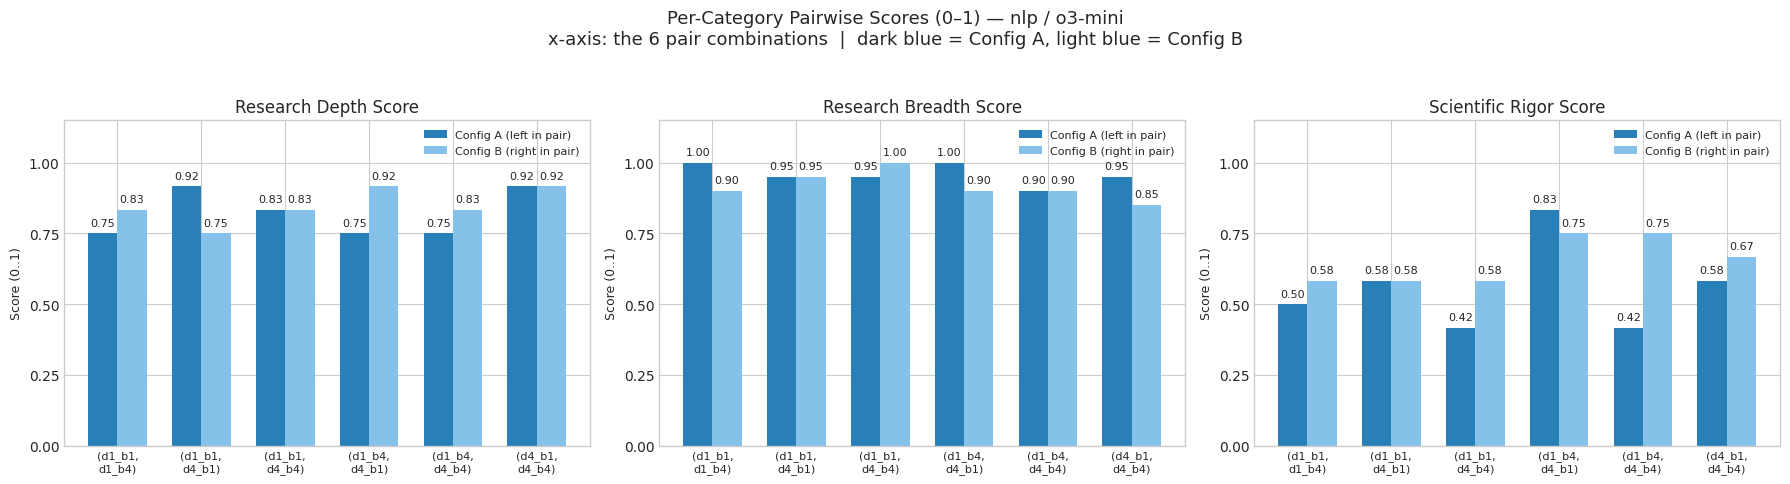

📊 Per-category pairwise score plot rendered
💾 Per-category plot → /nfs/home/gillm/deep-research/eval/output-nlp/pairwise_scores_per_category_nlp.png


In [23]:
# x-axis  : the 6 pair combinations in canonical order
# y-axis  : normalised score (0..1) from category_scores
# bars    : two per pair — Config A (dark blue) and Config B (light blue)
# panels  : one per active category (depth / breadth / rigor / innovation / gap)


RAW_DIMS = ['depth', 'breadth', 'rigor']
# RAW_DIMS = ['depth', 'breadth', 'rigor', 'innovation', 'gap']  

RAW_PANEL_TITLES = {
    'depth':   'Research Depth Score',
    'breadth': 'Research Breadth Score',
    'rigor':   'Scientific Rigor Score',
    # 'innovation': 'Innovation Score',
    # 'gap':        'Research Gap Score',
}

BAR_COLOR_A = '#2980b9'   # dark blue  — Config A
BAR_COLOR_B = '#85c1e9'   # light blue — Config B

ALL_CONFIGS = list(REPORT_POOL.keys())
ALL_PAIRS   = list(itertools.combinations(ALL_CONFIGS, 2))

# ── 1. Build per-dim data: (score_a, score_b) per pair ───────────────────────
dim_pair_data = {dim: [] for dim in RAW_DIMS}

for cfg_a, cfg_b in ALL_PAIRS:
    pair_key = f'{cfg_a}_vs_{cfg_b}'
    cat_scores = all_pair_results[pair_key]['category_scores']
    for dim in RAW_DIMS:
        scores = cat_scores.get(dim, {'a': 0.0, 'b': 0.0})
        dim_pair_data[dim].append((scores['a'], scores['b']))

# ── 2. Plot ───────────────────────────────────────────────────────────────────
n_dims    = len(RAW_DIMS)
n_pairs   = len(ALL_PAIRS)   # 6
xs_pairs  = np.arange(n_pairs)
BAR_W_RAW = 0.35

n_cols_raw = min(3, n_dims)
n_rows_raw = int(np.ceil(n_dims / n_cols_raw))

plt.style.use('seaborn-v0_8-whitegrid')
fig_raw, axes_raw = plt.subplots(
    n_rows_raw, n_cols_raw,
    figsize=(6 * n_cols_raw, 5 * n_rows_raw),
    squeeze=False,
)
axes_raw_flat = axes_raw.ravel()

for pi, dim in enumerate(RAW_DIMS):
    ax = axes_raw_flat[pi]
    panel_title = RAW_PANEL_TITLES[dim]
    pair_data   = dim_pair_data[dim]

    scores_a = [d[0] for d in pair_data]
    scores_b = [d[1] for d in pair_data]

    ax.bar(
        xs_pairs - BAR_W_RAW / 2, scores_a,
        width=BAR_W_RAW, color=BAR_COLOR_A, label='Config A (left in pair)',
    )
    ax.bar(
        xs_pairs + BAR_W_RAW / 2, scores_b,
        width=BAR_W_RAW, color=BAR_COLOR_B, label='Config B (right in pair)',
    )

    # Value labels
    for x, va, vb in zip(xs_pairs, scores_a, scores_b):
        if va:
            ax.text(x - BAR_W_RAW / 2, va + 0.02, f'{va:.2f}',
                    ha='center', va='bottom', fontsize=8)
        if vb:
            ax.text(x + BAR_W_RAW / 2, vb + 0.02, f'{vb:.2f}',
                    ha='center', va='bottom', fontsize=8)

    tick_labels = [f'({a},\n{b})' for a, b in ALL_PAIRS]
    ax.set_xticks(list(xs_pairs))
    ax.set_xticklabels(tick_labels, fontsize=8)

    ax.set_ylim(0, 1.15)
    ax.set_yticks([0.0, 0.25, 0.5, 0.75, 1.0])
    ax.set_ylabel('Score (0..1)', fontsize=9)
    ax.set_title(panel_title, fontsize=12)
    ax.legend(fontsize=8, loc='upper right')

# Hide spare axes
for j in range(pi + 1, len(axes_raw_flat)):
    axes_raw_flat[j].set_visible(False)

fig_raw.suptitle(
    f'Per-Category Pairwise Scores (0–1) — {DOMAIN} / {engine_str}\n'
    f'x-axis: the 6 pair combinations  |  dark blue = Config A, light blue = Config B',
    fontsize=13,
)
fig_raw.tight_layout(rect=[0, 0.02, 1, 0.94])
plt.show()
print('📊 Per-category pairwise score plot rendered')

# Optional: save
raw_fig_path = Path(OUTPUT_DIR) / f'pairwise_scores_per_category_{DOMAIN}.png'
fig_raw.savefig(raw_fig_path, dpi=200, bbox_inches='tight')
print(f'💾 Per-category plot → {raw_fig_path}')


## 9 — Final Evaluation Output (JSON)

Prints the full results dict covering all 6 pairs.

In [24]:
final_output = {
    'domain':       DOMAIN,
    'report_number': report_num,
    'question':     question,
    'model':        MODEL_ID,
    'pairs':        all_pair_results,   # keyed by 'cfg_a_vs_cfg_b'
}
display(Markdown('---\n### 🏁 Final Output\n---'))
print(json.dumps(final_output, indent=2, ensure_ascii=False))

---
### 🏁 Final Output
---

{
  "domain": "nlp",
  "report_number": 1,
  "question": "Robust Defenses against Many-Shot Jailbreaking",
  "model": "Qwen/Qwen3-1.7B",
  "pairs": {
    "d1_b1_vs_d1_b4": {
      "config_a": "d1_b1",
      "config_b": "d1_b4",
      "rubric_scores": {
        "TemporalPrecision": {
          "ResponseA": {
            "rating": 4,
            "rationale": "ResponseA includes specific temporal markers like 'September 05, 2025' in the abstract, but lacks consistent temporal precision elsewhere. While it mentions 'over 100 days' in the analysis, the use of vague terms like 'recently' and 'long-term' in sections (e.g., 'recently' in the introduction) reduces overall clarity. The response balances specific dates with general temporal language, achieving a moderate level of precision."
          },
          "ResponseB": {
            "rating": 4,
            "rationale": "ResponseB incorporates specific temporal references such as 'multi-stage attacker-defender models' and 'real-time syste

## 10 — Aggregated Per-Config Scores

Each config appears in **3 out of 6 pairs**. Here we collect all the scores a config
receives across every pair it participates in and compute the **mean ± std** for each
dimension. 


Aggregated scores (mean ± std across pairs):
  d1_b1:
    depth         0.833 ± 0.068
    breadth       0.967 ± 0.024
    rigor         0.500 ± 0.068
    overall       0.767 ± 0.036
  d1_b4:
    depth         0.778 ± 0.039
    breadth       0.933 ± 0.047
    rigor         0.611 ± 0.171
    overall       0.774 ± 0.070
  d4_b1:
    depth         0.861 ± 0.079
    breadth       0.933 ± 0.024
    rigor         0.639 ± 0.079
    overall       0.811 ± 0.039
  d4_b4:
    depth         0.861 ± 0.039
    breadth       0.917 ± 0.062
    rigor         0.667 ± 0.068
    overall       0.815 ± 0.009


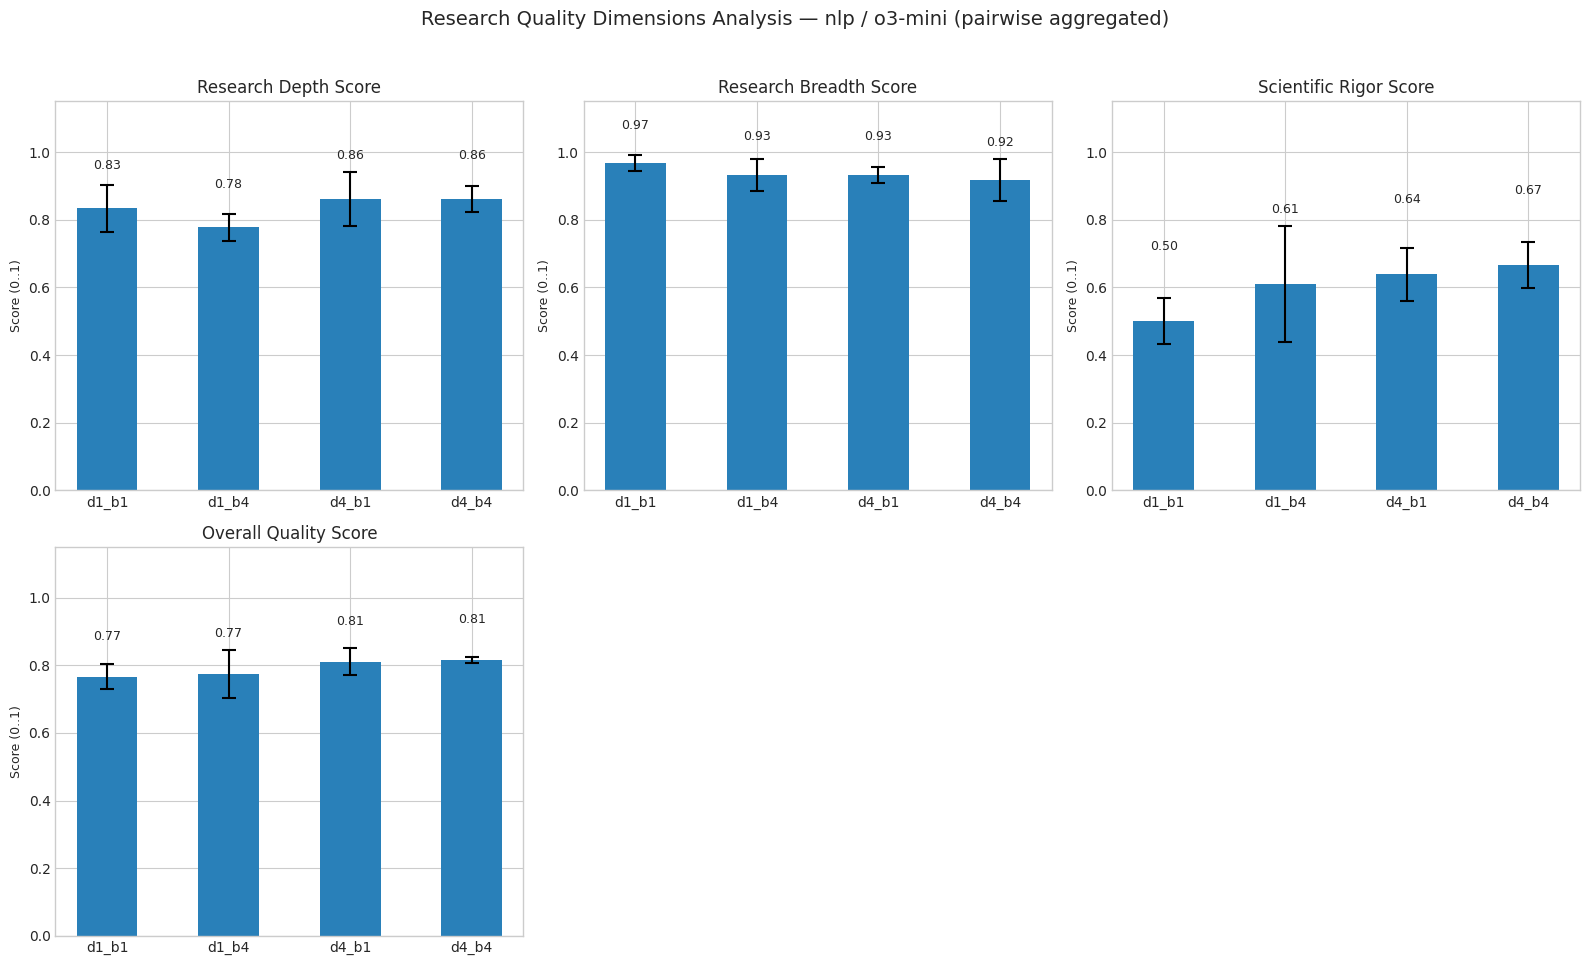

💾 Aggregated plot → /nfs/home/gillm/deep-research/eval/output-nlp/pairwise_aggregated_quality_dimensions_nlp.png


In [25]:
# ── 1. Dimensions to aggregate 
AGG_DIMS = ['depth', 'breadth', 'rigor']
# AGG_DIMS = ['depth', 'breadth', 'rigor', 'innovation', 'gap']  # uncomment when available

PANEL_TITLES_AGG = {
    'depth':      'Research Depth Score',
    'breadth':    'Research Breadth Score',
    'rigor':      'Scientific Rigor Score',
    # 'innovation': 'Innovation Score',       
    # 'gap':        'Research Gap Score',    
    'overall':    'Overall Quality Score',
}

# ── 2. Collect per-config scores from every pair ───────────────────────────────
# config_dim_scores[cfg][dim] = list of scores (one per pair the config appeared in)
config_dim_scores: dict = defaultdict(lambda: defaultdict(list))

for pair_key, res in all_pair_results.items():
    cfg_a = res['config_a']
    cfg_b = res['config_b']
    cat_scores = res['category_scores']
    overall_a  = res['overall_a']
    overall_b  = res['overall_b']

    for dim in AGG_DIMS:
        if dim in cat_scores:
            config_dim_scores[cfg_a][dim].append(cat_scores[dim]['a'])
            config_dim_scores[cfg_b][dim].append(cat_scores[dim]['b'])

    config_dim_scores[cfg_a]['overall'].append(overall_a)
    config_dim_scores[cfg_b]['overall'].append(overall_b)

# ── 3. Compute mean and std per config per dimension ──────────────────────────
# agg[cfg][dim] = (mean, std)
agg: dict = {}
for cfg in ALL_CONFIGS:
    agg[cfg] = {}
    for dim in list(PANEL_TITLES_AGG.keys()):
        vals = config_dim_scores[cfg].get(dim, [])
        if vals:
            agg[cfg][dim] = (float(np.mean(vals)), float(np.std(vals)))
        else:
            agg[cfg][dim] = (0.0, 0.0)

print('Aggregated scores (mean ± std across pairs):')
for cfg in ALL_CONFIGS:
    print(f'  {cfg}:')
    for dim, (mu, sd) in agg[cfg].items():
        print(f'    {dim:12s}  {mu:.3f} ± {sd:.3f}')

# ── 4. Plot ───────────────────────────────────────────────────────────────────
n_panels   = len(PANEL_TITLES_AGG)
n_cols     = 3
n_rows     = int(np.ceil(n_panels / n_cols))
BAR_W_AGG  = 0.18
xs_agg     = np.arange(len(ALL_CONFIGS))

plt.style.use('seaborn-v0_8-whitegrid')
fig_agg, axes_agg = plt.subplots(n_rows, n_cols, figsize=(16, 5 * n_rows))
axes_agg = np.array(axes_agg).ravel()

# Use the same blue palette as the pointwise plot
BAR_COLOR = '#2980b9'
ERR_COLOR = 'black'

for i, (dim, panel_title) in enumerate(PANEL_TITLES_AGG.items()):
    ax   = axes_agg[i]
    means = [agg[cfg][dim][0] for cfg in ALL_CONFIGS]
    stds  = [agg[cfg][dim][1] for cfg in ALL_CONFIGS]

    bars = ax.bar(
        xs_agg, means,
        width=0.5,
        color=BAR_COLOR,
        yerr=stds,
        capsize=5,
        error_kw=dict(ecolor=ERR_COLOR, lw=1.5, capthick=1.5),
    )

    for x, mu in zip(xs_agg, means):
        if mu:
            ax.text(x, mu + max(stds) + 0.03, f'{mu:.2f}',
                    ha='center', va='bottom', fontsize=9)

    ax.set_title(panel_title, fontsize=12)
    ax.set_xticks(list(xs_agg))
    ax.set_xticklabels(ALL_CONFIGS, fontsize=10)
    ax.set_ylim(0, 1.15)
    ax.set_ylabel('Score (0..1)', fontsize=9)

# Hide any spare axes
for j in range(i + 1, len(axes_agg)):
    axes_agg[j].set_visible(False)

fig_agg.suptitle(
    f'Research Quality Dimensions Analysis — {DOMAIN} / {engine_str} (pairwise aggregated)',
    fontsize=14,
)
fig_agg.tight_layout(rect=[0, 0.02, 1, 0.96])
plt.show()

# ── 5. Optional: save the aggregated plot ─────────────────────────────────────
agg_fig_path = Path(OUTPUT_DIR) / f'pairwise_aggregated_quality_dimensions_{DOMAIN}.png'
fig_agg.savefig(agg_fig_path, dpi=200, bbox_inches='tight')
print(f'💾 Aggregated plot → {agg_fig_path}')


## 11 — Save Raw Model Outputs to Disk

Saves a timestamped JSON file containing:
- All raw rubric ratings and rationales for every pair
- Evaluation **start/end timestamps**
- The **model** used for the reports 
- The **domain** and research question

File name pattern: `raw_output_{DOMAIN}_{model_slug}_{timestamp}.json`


In [29]:
# ── Save raw rubric outputs (ratings + rationales) to a timestamped JSON ────

# Record end time now (start time was captured when judge was initialised —
# we approximate it as the notebook kernel start; capture it here if not set)
if 'EVAL_START_TIME' not in dir():
    # Fallback: mark start as the beginning of this cell (conservative)
    EVAL_START_TIME = datetime.now(timezone.utc)

EVAL_END_TIME = datetime.now(timezone.utc)

# Sanitise model name for use in filename (replace / and spaces)
model_slug = MODEL_ID.replace('/', '--').replace(' ', '_')

# Judge identifier — CustomAutoJudge uses the same MODEL_ID by default;
# override JUDGE_ID in the config cell if a separate judge model is used
judge_id = getattr(judge, 'model_id', MODEL_ID)

timestamp_str = EVAL_END_TIME.strftime('%Y%m%d_%H%M%S')

# Build the raw output document
raw_output_doc = {
    'meta': {
        'domain':          DOMAIN,
        'report_number':   report_num,
        'question':        question,
        'model':           MODEL_ID,
        'eval_start_utc':  EVAL_START_TIME.isoformat(),
        'eval_end_utc':    EVAL_END_TIME.isoformat(),
        'eval_duration_s': round((EVAL_END_TIME - EVAL_START_TIME).total_seconds(), 1),
        'pairs_evaluated': len(all_pair_results)
    },
    'raw_rubric_outputs': {},
}

for pair_key, res in all_pair_results.items():
    pair_entry = {
        'config_a': res['config_a'],
        'config_b': res['config_b'],
        'rubrics':  {},
    }
    for rname, rdata in res['rubric_scores'].items():
        pair_entry['rubrics'][rname] = {
            'ResponseA': {
                'rating':    rdata['ResponseA']['rating'],
                'rationale': rdata['ResponseA']['rationale'],
            },
            'ResponseB': {
                'rating':    rdata['ResponseB']['rating'],
                'rationale': rdata['ResponseB']['rationale'],
            },
        }
    raw_output_doc['raw_rubric_outputs'][pair_key] = pair_entry

# Filename encodes model + domain + timestamp for easy identification
raw_out_filename = f'raw_output_{DOMAIN}_{model_slug}_{timestamp_str}.json'
raw_out_path = Path(OUTPUT_DIR) / raw_out_filename
raw_out_path.write_text(
    json.dumps(raw_output_doc, indent=2, ensure_ascii=False),
    encoding='utf-8',
)

print(f'💾 Raw output saved → {raw_out_path}')
print(f'   Model   : {MODEL_ID}')
print(f'   Start   : {EVAL_START_TIME.isoformat()}')
print(f'   End     : {EVAL_END_TIME.isoformat()}')
print(f'   Duration: {raw_output_doc["meta"]["eval_duration_s"]} s')
print(f'   Pairs   : {len(all_pair_results)}')
print()
display(Markdown('---\n### 🗂️ Raw Output Preview\n---'))
print(json.dumps(raw_output_doc['meta'], indent=2))


💾 Raw output saved → /nfs/home/gillm/deep-research/eval/output-nlp/raw_output_nlp_Qwen--Qwen3-1.7B_20260504_200134.json
   Model   : Qwen/Qwen3-1.7B
   Start   : 2026-05-04T12:56:14.324662+00:00
   End     : 2026-05-04T20:01:34.115954+00:00
   Duration: 25519.8 s
   Pairs   : 6



---
### 🗂️ Raw Output Preview
---

{
  "domain": "nlp",
  "report_number": 1,
  "question": "Robust Defenses against Many-Shot Jailbreaking",
  "model": "Qwen/Qwen3-1.7B",
  "eval_start_utc": "2026-05-04T12:56:14.324662+00:00",
  "eval_end_utc": "2026-05-04T20:01:34.115954+00:00",
  "eval_duration_s": 25519.8,
  "pairs_evaluated": 6
}
